In [1]:
# MDP exploration setup
# This notebook demonstrates:
# 1) expected-score heatmaps over a hole image,
# 2) optimal action visualization (club + aim),
# 3) per-state expected score queries.

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Exploration" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Simulation.holecomponent import HoleComponent
from Simulation.golfhole import Hole
from Models.MDP import GolfHoleMDP
from Models.TrainGaussian import train_gaussian_mixture
from Utils.preprocess import preprocess_data

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/epicxflipper/UBC/CPSC440/CPSC_440_Project


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


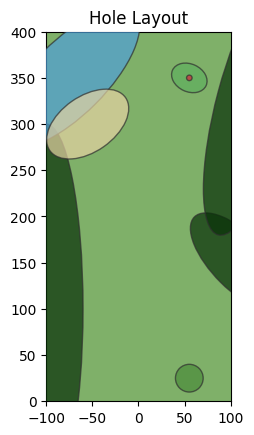

In [2]:
# Build the same hole geometry used in Simulation/HoleSetUp/hole1.py

def build_hole_1():
    components = [
        HoleComponent(center=(55, 350), semi_major_axis=20, semi_minor_axis=15, rotation=-25, comp_type="green"),
        HoleComponent(center=(55, 25), semi_major_axis=15, semi_minor_axis=15, rotation=0, comp_type="tee"),
        HoleComponent(center=(-100, 100), semi_major_axis=40, semi_minor_axis=200, rotation=0, comp_type="tree"),
        HoleComponent(center=(-75, 350), semi_major_axis=40, semi_minor_axis=100, rotation=-45, comp_type="water"),
        HoleComponent(center=(-55, 300), semi_major_axis=30, semi_minor_axis=50, rotation=-55, comp_type="bunker"),
        HoleComponent(center=(110, 150), semi_major_axis=70, semi_minor_axis=30, rotation=-45, comp_type="tree"),
        HoleComponent(center=(125, 325), semi_major_axis=40, semi_minor_axis=150, rotation=-15, comp_type="tree"),
        HoleComponent(center=(55, 350), semi_major_axis=3, semi_minor_axis=3, rotation=0, comp_type="pin"),
    ]

    hole = Hole(
        size=(200, 400),
        components=components,
        pin_location=(55, 350),
        tee_location=(55, 25),
    )
    return hole

hole = build_hole_1()
fig, ax = hole.draw()
ax.set_title("Hole Layout")
plt.show()

In [3]:
# Fit one GMM per club from Data/RG_Data.csv.
# We model each shot as [lateral_offset, distance].


DATA_PATH = PROJECT_ROOT / "Data" / "RG_Data.csv"
PLAYER_NAME = "2"
MAX_COMPONENTS = 10
MIN_SHOTS_PER_CLUB = 10

raw = preprocess_data()
player_df = raw[raw["Name"] == PLAYER_NAME].copy()

if player_df.empty:
    raise ValueError(f"No rows found for player '{PLAYER_NAME}' in {DATA_PATH}.")

gmm_list = []
club_names = []

for club, club_df in sorted(player_df.groupby("Club"), key=lambda x: x[0]):
    if len(club_df) < MIN_SHOTS_PER_CLUB:
        continue

    club_data = club_df.dropna(subset=["X", "Y"]).copy()
    idx, gmms, model_scores = train_gaussian_mixture(club_data, max_components=MAX_COMPONENTS)
    model = gmms[idx]

    gmm_list.append(model)
    club_names.append(club)

if not gmm_list:
    raise ValueError(
        "No club had enough shots to fit a GMM. Lower MIN_SHOTS_PER_CLUB or collect more data."
    )

# Add synthetic short-game clubs for around-the-green play.
class DeterministicShotModel:
    def __init__(self, lateral=0.0, distance=3.0):
        self.point = np.array([float(lateral), float(distance)], dtype=float)

    def sample(self, n_samples):
        samples = np.repeat(self.point[None, :], repeats=n_samples, axis=0)
        labels = np.zeros(n_samples, dtype=int)
        return samples, labels


def make_tight_synthetic_club(distance_yards, lateral_std=0.05, distance_std=0.10, n_samples=200):
    lateral = np.random.normal(loc=0.0, scale=lateral_std, size=n_samples)
    distance = np.random.normal(loc=distance_yards, scale=distance_std, size=n_samples)
    data = np.column_stack([lateral, distance])
    gmm = GaussianMixture(n_components=1, random_state=42)
    gmm.fit(data)
    return gmm

gmm_list.append(DeterministicShotModel(lateral=0.0, distance=3.0))
club_names.append("PUTTER_3Y")

synthetic_wedges = [
    ("WEDGE_10Y", 10.0),
    ("WEDGE_20Y", 20.0),
    ("WEDGE_30Y", 30.0),
    ("WEDGE_40Y", 40.0),
]

for club_name, carry in synthetic_wedges:
    gmm_list.append(make_tight_synthetic_club(carry))
    club_names.append(club_name)

mdp = GolfHoleMDP(hole=hole, gmm_list=gmm_list)

print(f"Player: {PLAYER_NAME}")
print(f"Clubs used ({len(club_names)}): {club_names}")

Combined dataset shape: (1633, 4)
Initialized MDP with 861 discrete states
Player: 2
Clubs used (7): ['I7', 'W1', 'PUTTER_3Y', 'WEDGE_10Y', 'WEDGE_20Y', 'WEDGE_30Y', 'WEDGE_40Y']


In [4]:
# Use MDP.py value iteration/action generation directly (no duplicated VI logic in notebook).

def make_plot_grid(mdp, x_step=10, y_step=10):
    x_vals = np.arange(mdp.x_min, mdp.x_max + 1e-9, x_step)
    y_vals = np.arange(mdp.y_min, mdp.y_max + 1e-9, y_step)
    states = [(float(x), float(y)) for y in y_vals for x in x_vals]
    return x_vals, y_vals, states


def _progress(iterable, show_progress=True, **kwargs):
    if not show_progress:
        return iterable
    try:
        from tqdm.auto import tqdm as _tqdm
        return _tqdm(iterable, **kwargs)
    except ImportError:
        return iterable


def derive_greedy_policy(
    mdp,
    value_function,
    states,
    gamma=0.98,
    num_angle_samples=30,
    eval_samples=20,
    optimize="min",
    show_progress=True,
    progress_desc="Deriving greedy policy",
):
    policy = {}

    state_iterable = _progress(
        states,
        show_progress=show_progress,
        desc=progress_desc,
        unit="state",
    )

    for s in state_iterable:
        if mdp.is_terminal_state(s):
            policy[s] = None
            continue

        best_score = np.inf if optimize == "min" else -np.inf
        best_action = None

        for a in mdp.get_possible_actions(s, num_angle_samples=num_angle_samples):
            reward, next_dist = mdp.step(s, a, num_samples=eval_samples)
            continuation = 0.0
            for ns, p in next_dist.items():
                continuation += p * value_function.get(ns, 0.0)

            score = reward + gamma * continuation

            if optimize == "min":
                if score < best_score:
                    best_score = score
                    best_action = a
            else:
                if score > best_score:
                    best_score = score
                    best_action = a

        policy[s] = best_action

    return policy

print("Defined helpers that use GolfHoleMDP.value_iteration and GolfHoleMDP.get_possible_actions.")

Defined helpers that use GolfHoleMDP.value_iteration and GolfHoleMDP.get_possible_actions.


Precomputing transitions for 861 states...


Precomputing transitions:   0%|          | 0/861 [00:00<?, ?state/s]

Precomputing transitions: 100%|██████████| 861/861 [41:32<00:00,  2.89s/state]


Cached 36162 state-action transitions


Deriving greedy policy: 100%|██████████| 861/861 [1:27:41<00:00,  6.11s/state]


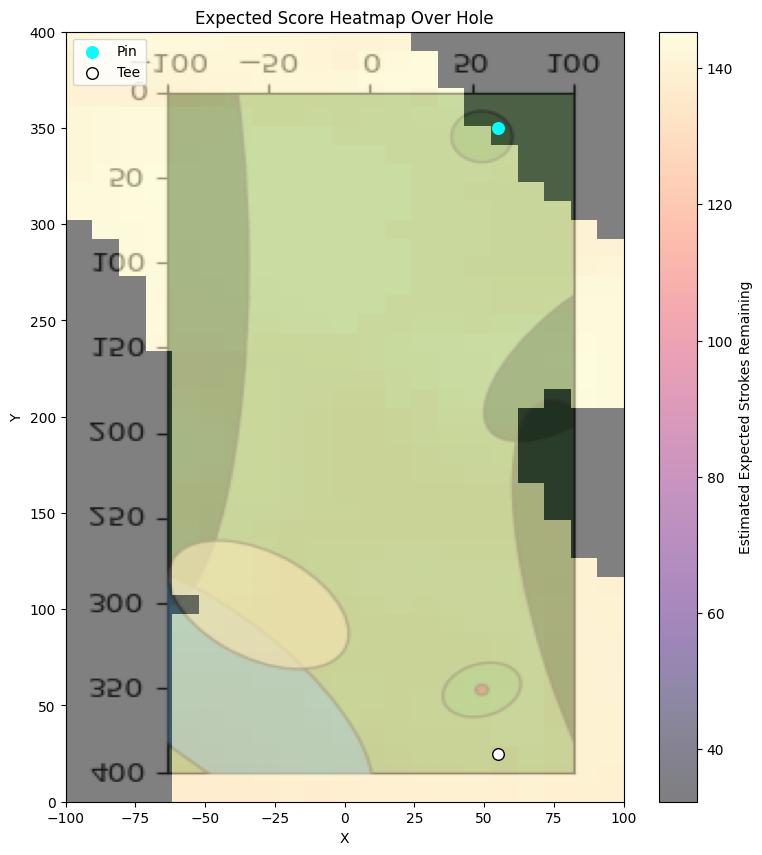

In [ ]:
# 1) Heatmap: expected score from each position, overlaid on rendered hole image.

# Plotting / policy-resolution controls.
GRID_X_STEP = mdp.grid_step
GRID_Y_STEP = mdp.grid_step
GAMMA = 0.98
VI_ITERS = 12
VI_EPSILON = 1e-3
NUM_ANGLE_SAMPLES = 12
SAMPLES_PER_ACTION = 20
SHOW_PROGRESS = True
SHOW_VI_STATE_PROGRESS = True

# Run value iteration with optimized settings
GAMMA = 0.98
VI_ITERS = 12
VI_EPSILON = 1e-3

# These control the precomputation step
PRECOMPUTE_ANGLE_SAMPLES = 5  # Fewer angles for precomputation = faster
PRECOMPUTE_SHOT_SAMPLES = 20  # Samples per action during precomputation

# First, precompute all transitions (one-time cost)
mdp.precompute_transitions(num_samples=PRECOMPUTE_SHOT_SAMPLES, show_progress=True)

# Now run value iteration (should be MUCH faster)
value_function = mdp.value_iteration(
    max_iterations=VI_ITERS,
    discount_factor=GAMMA,
    epsilon=VI_EPSILON,
    show_progress=True,
    num_angle_samples=PRECOMPUTE_ANGLE_SAMPLES,  # Must match precompute
    num_samples=PRECOMPUTE_SHOT_SAMPLES,  # Must match precompute
)

x_vals, y_vals, plot_states = make_plot_grid(
    mdp,
    x_step=GRID_X_STEP,
    y_step=GRID_Y_STEP,
)

policy = derive_greedy_policy(
    mdp,
    value_function,
    plot_states,
    gamma=GAMMA,
    num_angle_samples=NUM_ANGLE_SAMPLES,
    eval_samples=SAMPLES_PER_ACTION,
    optimize="min",
    show_progress=SHOW_PROGRESS,
    progress_desc="Deriving greedy policy",
)

# Convert value map to expected strokes map.
# Values are penalty-like, so expected strokes is approximated by -value.
score_grid = np.zeros((len(y_vals), len(x_vals)), dtype=float)
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        score_grid[iy, ix] = max(0.0, -value_function.get((float(x), float(y)), 0.0))

hole_img_path = PROJECT_ROOT / "Simulation" / "HoleRendering" / "hole.png"
if not hole_img_path.exists():
    hole.draw()

img = plt.imread(hole_img_path)

# Use a darker, banded palette so differences in stroke counts stand out more
# against the course image.
max_score = float(np.max(score_grid)) if score_grid.size else 1.0
max_score = max(1.0, max_score)
num_bands = 8
boundaries = np.linspace(0.0, max_score, num_bands + 1)
shot_cmap = ListedColormap(plt.cm.inferno(np.linspace(0.15, 0.95, num_bands)))
shot_norm = BoundaryNorm(boundaries, shot_cmap.N, clip=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.imshow(img, extent=[mdp.x_min, mdp.x_max, mdp.y_min, mdp.y_max], origin="lower", alpha=0.8)

heat = ax.imshow(
    score_grid,
    extent=[x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]],
    origin="lower",
    cmap=shot_cmap,
    norm=shot_norm,
    alpha=0.85,
    aspect="auto",
)

cbar = plt.colorbar(heat, ax=ax, boundaries=boundaries, ticks=np.linspace(0.0, max_score, 5))
cbar.set_label("Estimated Expected Strokes Remaining")

ax.scatter([mdp.pin_location[0]], [mdp.pin_location[1]], c="cyan", s=70, label="Pin")
ax.scatter([mdp.tee_location[0]], [mdp.tee_location[1]], c="white", s=70, edgecolors="black", label="Tee")
ax.set_xlim(mdp.x_min, mdp.x_max)
ax.set_ylim(mdp.y_min, mdp.y_max)
ax.set_title("Expected Score Heatmap Over Hole")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc="upper left")
plt.show()

In [6]:
import pickle
import json
from pathlib import Path

class MDPResultsCache:
    """Helper class to save/load MDP computation results."""
    
    def __init__(self, cache_dir="mdp_cache"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
    
    def _get_cache_filename(self, player_name, grid_step, num_clubs, hole_id=None):
        """Generate unique cache filename based on problem parameters."""
        hole_str = f"_hole{hole_id}" if hole_id else ""
        return f"mdp_player{player_name}_grid{grid_step}_clubs{num_clubs}{hole_str}.pkl"
    
    def save_results(self, value_function, policy, transition_cache, 
                     player_name, grid_step, num_clubs, hole_id=None, metadata=None):
        """
        Save all computed results to disk.
        
        Args:
            value_function: Dict mapping states to values
            policy: Dict mapping states to actions
            transition_cache: Dict mapping (state, action) to (reward, next_state_dist)
            player_name: Player identifier
            grid_step: Grid discretization step size
            num_clubs: Number of clubs used
            hole_id: Optional hole identifier
            metadata: Optional dict with additional info (VI params, club names, etc.)
        """
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        filepath = self.cache_dir / filename
        
        results = {
            'value_function': value_function,
            'policy': policy,
            'transition_cache': transition_cache,
            'metadata': metadata or {},
            'player_name': player_name,
            'grid_step': grid_step,
            'num_clubs': num_clubs,
            'hole_id': hole_id,
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
        
        print(f"Saved MDP results to {filepath}")
        print(f"  - {len(value_function)} states in value function")
        print(f"  - {len(policy)} states in policy")
        print(f"  - {len(transition_cache)} cached transitions")
        
        return filepath
    
    def load_results(self, player_name, grid_step, num_clubs, hole_id=None):
        """
        Load previously computed results.
        
        Returns:
            dict with keys: value_function, policy, transition_cache, metadata
            or None if cache doesn't exist
        """
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        filepath = self.cache_dir / filename
        
        if not filepath.exists():
            print(f"No cache found at {filepath}")
            return None
        
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
        
        print(f"Loaded MDP results from {filepath}")
        print(f"  - {len(results['value_function'])} states in value function")
        print(f"  - {len(results['policy'])} states in policy")
        print(f"  - {len(results['transition_cache'])} cached transitions")
        if results['metadata']:
            print(f"  - Metadata: {results['metadata']}")
        
        return results
    
    def cache_exists(self, player_name, grid_step, num_clubs, hole_id=None):
        """Check if cache file exists for given parameters."""
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        return (self.cache_dir / filename).exists()

In [8]:
mdp_cache = MDPResultsCache()
mdp_cache.save_results(
    value_function=value_function,
    policy=policy,
    transition_cache=mdp._transition_cache,
    player_name=PLAYER_NAME,
    grid_step=GRID_X_STEP,
    num_clubs=len(club_names),
    hole_id="hole1",
    metadata={
        "gamma": GAMMA,
        "vi_iters": VI_ITERS,
        "vi_epsilon": VI_EPSILON,
        "num_angle_samples": NUM_ANGLE_SAMPLES,
        "samples_per_action": SAMPLES_PER_ACTION,
        "club_names": club_names,
    }
)

Saved MDP results to mdp_cache/mdp_player2_grid10_clubs7_holehole1.pkl
  - 861 states in value function
  - 861 states in policy
  - 36162 cached transitions


PosixPath('mdp_cache/mdp_player2_grid10_clubs7_holehole1.pkl')

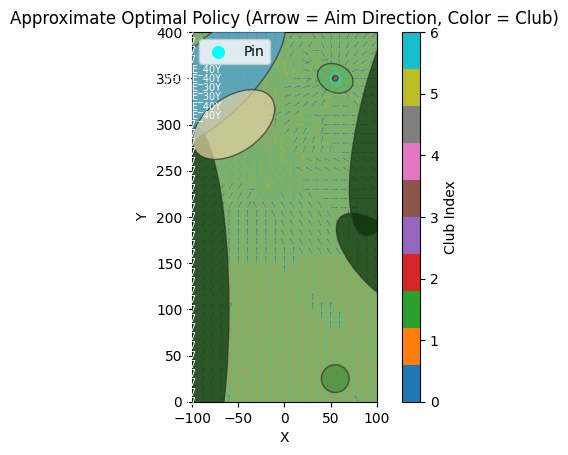

In [11]:
# 2) Optimal policy visualization: at each state, what to aim at and what club to hit.

# Build quiver vectors and annotate each arrow with club label.
X, Y, U, VEC = [], [], [], []
club_for_state = []

for y in y_vals:
    for x in x_vals:
        s = (float(x), float(y))
        a = policy.get(s)
        if a is None:
            continue

        club_idx, tx, ty = a
        dx = tx - x
        dy = ty - y
        norm = np.hypot(dx, dy)
        if norm < 1e-9:
            continue

        # Normalize for readable arrows on dense grids.
        scale = 8.0 / norm
        X.append(x)
        Y.append(y)
        U.append(dx * scale)
        VEC.append(dy * scale)
        club_for_state.append(club_idx)

# Draw directly on the hole axes so the policy vectors use the same
# coordinate system as the hole geometry.
fig, ax = hole.draw()

q = ax.quiver(
    X,
    Y,
    U,
    VEC,
    club_for_state,
    cmap="tab10",
    angles="xy",
    scale_units="xy",
    scale=1,
    pivot="tail",
)
cb = plt.colorbar(q, ax=ax)
cb.set_label("Club Index")

# Label a sparse subset to keep figure legible.
for idx in range(0, len(X), max(1, len(X) // 40)):
    cidx = club_for_state[idx]
    label = club_names[cidx] if cidx < len(club_names) else f"club_{cidx}"
    ax.text(X[idx], Y[idx], label, fontsize=7, color="white", ha="center", va="center")

ax.scatter([mdp.pin_location[0]], [mdp.pin_location[1]], c="cyan", s=70, label="Pin")
ax.set_xlim(mdp.x_min, mdp.x_max)
ax.set_ylim(mdp.y_min, mdp.y_max)
ax.set_title("Approximate Optimal Policy (Arrow = Aim Direction, Color = Club)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc="upper left")
plt.show()

In [ ]:
def get_best_action(state, policy, mdp):
    """
    Get the best action to take from a given state.
    
    Args:
        state: (x, y) tuple representing ball position
        policy: Dict mapping states to best actions (from derive_greedy_policy)
        mdp: GolfHoleMDP object
    
    Returns:
        (club_index, target_x, target_y) or None if terminal state
    """
    # Snap to nearest grid state since policy is discretized
    grid_state = mdp._snap_to_grid(state[0], state[1])
    
    if grid_state in policy:
        return policy[grid_state]
    
    # If state not in policy, find nearest state
    nearest_state = mdp._find_nearest_state(grid_state, list(policy.keys()))
    return policy.get(nearest_state)


# Example usage:
current_position = (25.0, 150.0)  # Ball at x=25, y=150
best_action = get_best_action(current_position, policy, mdp)

if best_action is None:
    print("Already at the pin!")
else:
    club_idx, target_x, target_y = best_action
    print(f"Best action from {current_position}:")
    print(f"  Club: {club_names[club_idx]}")
    print(f"  Aim at: ({target_x:.1f}, {target_y:.1f})")

NameError: name 'value_at_state' is not defined